# Customer Purchasing, Segmentation & Retention

## tl;dr
The 1,725 loyal/recent customers represent 39.76% of identified customers and 79.60% of eligible gross purchase value. Next-month retention is 19.94% across equally observed Jan–Oct 2011 cohorts. Test outreach; do not equate historical spend with recoverable revenue.

Full dataset run. Historical portfolio case study prepared with AI assistance; no operational intervention was implemented.

## Context & Methods
Audience: retail marketing. Unit: identified customers and first-observed purchase cohorts. Cleaning and RFM logic live in `src/analyze.py`; cohort and plotting code in `build_portfolio.py`.

### Key Assumptions
Read [methods](docs/methodology.md) for exclusions and denominator choices. Exact duplicates are removed. Positive identified purchases define gross spend; refunds are excluded. Recency is measured at December 10, 2011. Future cohort cells remain missing and partial December 2011 is excluded.

## Data
Run `python download_data.py` once before this notebook. Source files remain in `data/raw/` and are not published. Download links, licensing, and provenance are in the [README](README.md). The following cell rebuilds results directly from the original files.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, SVG
from build_portfolio import build, charts
summary = build()
print(summary['validation'])

PASS: exclusions, distinct invoices, customer counts and spend reconcile


### Review aggregate evidence
Tables below are generated by the pipeline; they are not manually entered.

In [2]:
import pandas as pd
from IPython.display import display
table = pd.read_csv('results/segment_summary.csv')
display(table[['segment', 'customers', 'gross_purchase_value_gbp', 'spend_share_pct']].rename(columns={'gross_purchase_value_gbp': 'Gross value (GBP)', 'spend_share_pct': 'Value share (%)'}).round(2))

,segment,customers,Gross value (GBP),Value share (%)
0,Lapsed repeat,602,676302.49,7.61
1,Loyal / recent,1725,7073910.84,79.60
2,Other / lapsed,847,356239.80,4.01
3,Recent occasional,1164,780755.76,8.79


## Results
Figures are generated by the editable plotting functions in `build_portfolio.py`. Source result CSVs remain available for inspection.

In [3]:
figures = charts()
plt.close('all')

### Customer Segments

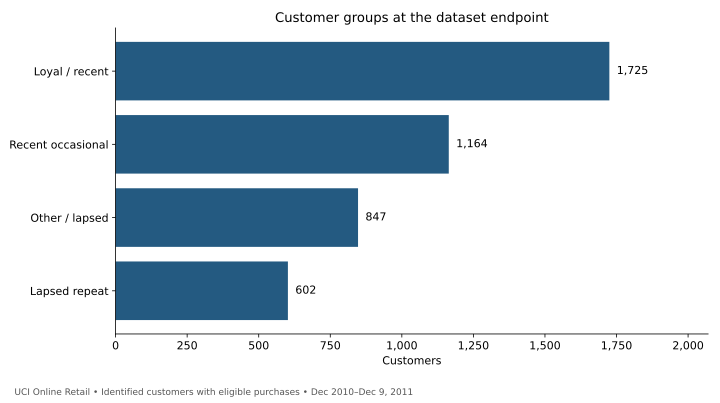

In [4]:
display(SVG(filename='charts/customer_segments.svg'))

Customer groups use explicit recency/frequency rules. They are operational definitions rather than predictions.

### Segment Spending

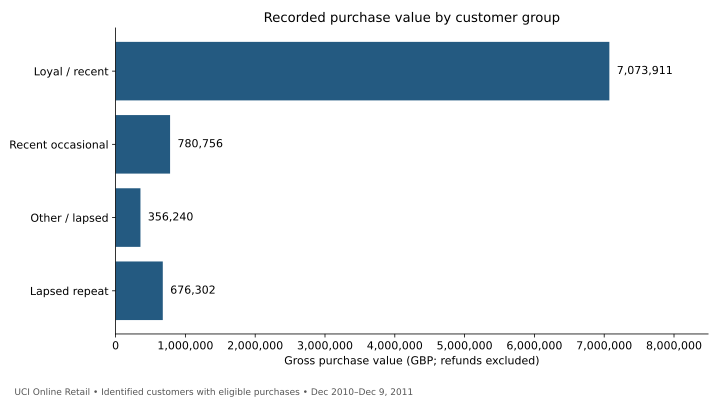

In [5]:
display(SVG(filename='charts/segment_spending.svg'))

Loyal/recent customers account for 79.60% of eligible gross purchase value. Refunds are excluded, and the top approximately 1% of spenders contribute 32.06%.

### Purchase Frequency

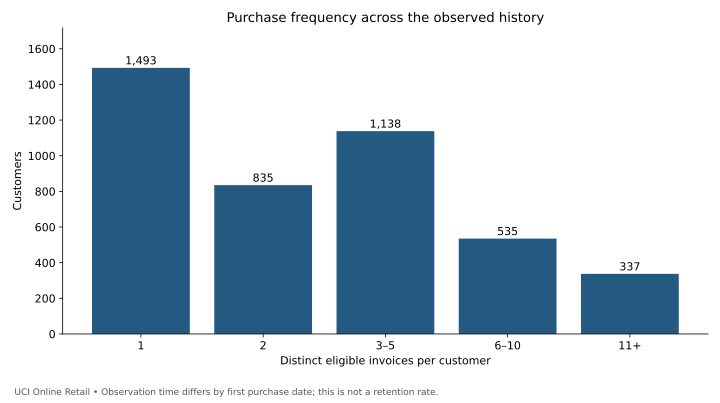

In [6]:
display(SVG(filename='charts/purchase_frequency.svg'))

1,493 customers have one eligible invoice; 2,845 have multiple invoices. Observation time differs across customers, so this is not an equal-window retention measure.

### Cohort Retention

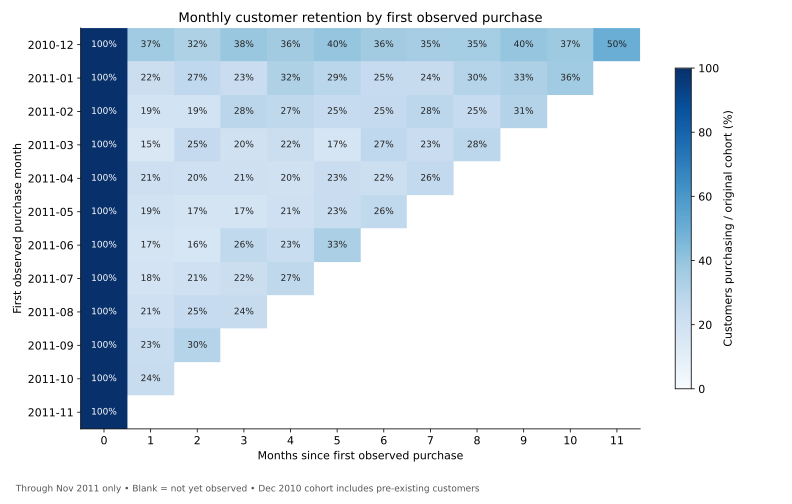

In [7]:
display(SVG(filename='charts/cohort_retention.svg'))

The heatmap compares original-cohort purchasing rates by calendar-month age. Blank cells are unobserved. The December 2010 cohort includes pre-existing customers; partial December 2011 is excluded.

## Takeaways
The 1,725 loyal/recent customers represent 39.76% of identified customers and 79.60% of eligible gross purchase value. Next-month retention is 19.94% across equally observed Jan–Oct 2011 cohorts. Test outreach; do not equate historical spend with recoverable revenue.

Read the [findings and proposed actions](docs/findings.md) and [interview guide](docs/interview-guide.md). Key calculations reconcile in the build assertions. Descriptive findings do not establish campaign lift, causal delivery impact, or current market performance.